STARTING ROBUST 2-STAGE STAT-ARB ENGINE (TRUNCATED GHOST -> KRLS ALPHA-TILT SLSQP)
[2024-08-28] Ghost=31 | Live=13 | Gross=1.79 | Mean KRLS Conviction=0.50
[2024-08-29] Ghost=31 | Live=9 | Gross=1.80 | Mean KRLS Conviction=0.71
[2024-08-30] Ghost=29 | Live=12 | Gross=1.80 | Mean KRLS Conviction=0.70
[2024-09-03] Ghost=30 | Live=10 | Gross=1.80 | Mean KRLS Conviction=0.56
[2024-09-04] Ghost=28 | Live=9 | Gross=1.79 | Mean KRLS Conviction=0.55
[2024-09-05] Ghost=27 | Live=8 | Gross=1.79 | Mean KRLS Conviction=0.66
[2024-09-06] Ghost=22 | Live=8 | Gross=1.80 | Mean KRLS Conviction=0.70
[2024-09-09] Ghost=20 | Live=9 | Gross=1.80 | Mean KRLS Conviction=0.73
[2024-09-10] Ghost=17 | Live=8 | Gross=1.80 | Mean KRLS Conviction=0.73
[2024-09-11] Ghost=16 | Live=8 | Gross=1.80 | Mean KRLS Conviction=0.73
[2024-09-12] Ghost=18 | Live=9 | Gross=1.80 | Mean KRLS Conviction=0.72
[2024-09-13] Ghost=24 | Live=9 | Gross=1.80 | Mean KRLS Conviction=0.71
[2024-09-16] Ghost=21 | Live=8 | Gross=1.80 | Mean

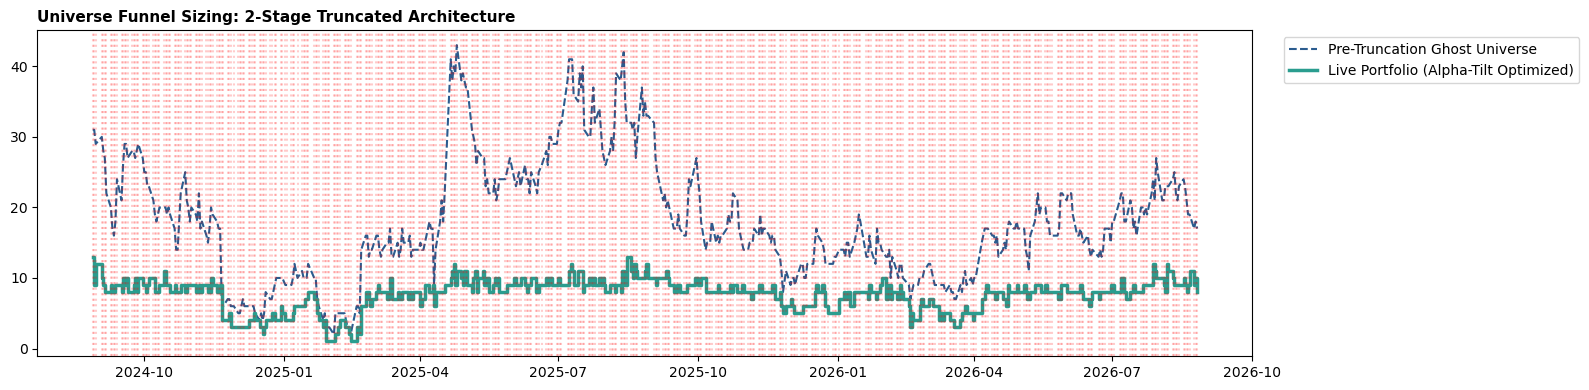

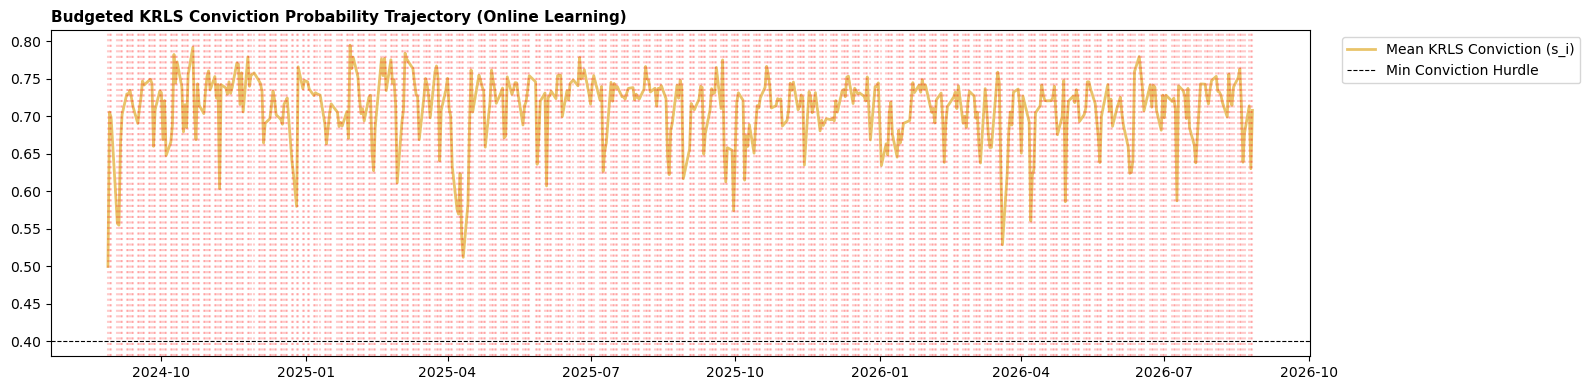

In [7]:
# ==============================================================================
# S&P 500 STAT-ARB PIPELINE: ROBUST 2-STAGE ARCHITECTURE (KRLS EDITION)
# ==============================================================================
import os
import gc
import pickle
import warnings
from typing import Dict, List, Tuple, Optional
from collections import deque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import chi2, t as student_t
from scipy.spatial.distance import cdist
from scipy.optimize import minimize as scipy_minimize
import vectorbt as vbt
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")
pd.set_option('display.max_rows', 250)
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_id = "model_A_krls"

# ==============================================================================
# 1. INSTITUTIONAL PARAMETER CONFIGURATION
# ==============================================================================
run_params = {
    "price_csv": "data/universe_daily_train.csv",
    "oos_price_csv": "data/universe_daily_val.csv",
    "constituents_path": "data/constituents.csv",
    "state_persistence_file": f"artifacts/{model_id}/stat_arb_state_{timestamp}.pkl",

    "lookback_days": 504,             
    "min_history_days": 100,          
    "screening_freq_days": 20,          
    "quarantine_days": 63,              
    
    "kalman_delta": 1e-4,              
    "kalman_obs_noise": 1e-3,          
    "kalman_z_window": 21,             
    "max_hurst_exponent": 0.52,        
    
    "min_correlation": 0.45,          
    "p_value_threshold": 0.10,         
    
    "min_half_life": 3.0,             
    "max_half_life": 30.0,            
    "tau_hl_penalty": 5.0,             
    
    "exit_z_spread": 0.20,            
    "stop_loss_z": 2.75,               
    "bocpd_cp_threshold": 0.35,        
    
    # BUDGETED KRLS & TRUNCATION PARAMS
    "krls_dict_budget": 100,
    "krls_kernel_bandwidth": 2.0,
    "krls_regularization": 0.01,
    "min_conviction": 0.40,
    "promote_top_n": 20,              
    "ghost_truncation_quantile": 0.60, # Drops bottom 60% of universe before SLSQP
    
    # SLSQP RISK & ALPHA BOUNDS
    "obj_alpha_return": 1.5,           # Reward multiplier for Alpha-Tilt objective
    "max_gross_exposure": 1.8,        
    "max_sleeve_weight": 0.25,        

    "initial_capital": 250_000.0,
    "exec_fee": 0.00015,              
    "borrow_bps": 50.0
}

# ==============================================================================
# 2. STATE PERSISTENCE ENGINE
# ==============================================================================
class StatePersistenceEngine:
    @staticmethod
    def save_checkpoint(filepath: str, state_dict: dict):
        try:
            os.makedirs(os.path.dirname(filepath), exist_ok=True)
            with open(filepath, "wb") as f:
                pickle.dump(state_dict, f)
        except Exception as e:
            print(f"[State Engine Error] Save failed: {str(e)}", flush=True)

    @staticmethod
    def load_checkpoint(filepath: str) -> Optional[dict]:
        if not os.path.exists(filepath): return None
        try:
            with open(filepath, "rb") as f:
                return pickle.load(f)
        except Exception:
            return None

# ==============================================================================
# 3. MATH & KALMAN UTILITIES
# ==============================================================================
def calculate_half_life_fast(spread: np.ndarray) -> float:
    if len(spread) < 30: return 25.0
    s_lag, s_diff = spread[:-1], spread[1:] - spread[:-1]
    var_x = np.sum((s_lag - np.mean(s_lag))**2)
    if var_x < 1e-12: return 25.0
    gamma = np.sum((s_lag - np.mean(s_lag)) * (s_diff - np.mean(s_diff))) / var_x
    if gamma <= -1.0: return 1.0
    if gamma >= 0.0: return np.inf
    return float(-0.6931471805599453 / np.log(1.0 + gamma))

def compute_hurst_exponent_fast(time_series: np.ndarray, max_lag: int = 20) -> float:
    N = len(time_series)
    if N < max_lag * 2: return 0.50
    lags = np.arange(2, max_lag)
    tau = [np.std(time_series[lag:] - time_series[:-lag]) for lag in lags]
    slope = np.polyfit(np.log(lags), np.log(np.maximum(tau, 1e-8)), 1)[0]
    return float(slope * 2.0)

def compute_trade_reward(entry_z: float, exit_z: float, days_held: float, half_life: float) -> float:
    """Proxy reward function to train KRLS upon trade exit."""
    abs_entry = max(0.1, abs(entry_z))
    abs_exit = abs(exit_z)
    z_capture_efficiency = (abs_entry - abs_exit) / abs_entry
    hl_ratio = days_held / max(1.0, half_life)
    duration_factor = np.exp(-0.30 * max(0.0, hl_ratio - 1.0))
    if abs_exit >= abs_entry: return -1.0 # Stopped out
    return float(np.clip(2.0 * z_capture_efficiency * duration_factor, -1.0, 1.0))

class FastKalmanFilter:
    def __init__(self, delta: float = 1e-4, obs_noise: float = 1e-3, z_window: int = 21):
        self.delta, self.obs_noise, self.z_window = delta, obs_noise, z_window
        self.Q = (delta / (1.0 - delta)) * np.eye(2, dtype=np.float64)

    def filter_series(self, y: np.ndarray, x: np.ndarray) -> Dict[str, np.ndarray]:
        N = len(y)
        state_mean, state_cov = np.zeros(2, dtype=np.float64), np.eye(2, dtype=np.float64)
        betas, alphas, v_arr = np.empty(N), np.empty(N), np.empty(N)
        H = np.ones((2, 1), dtype=np.float64)
        for t in range(N):
            H[1, 0] = x[t]
            pred_cov = state_cov + self.Q
            v = y[t] - (H.T @ state_mean).item()
            F = (H.T @ pred_cov @ H).item() + self.obs_noise
            K = (pred_cov @ H) / F
            state_mean += (K.flatten() * v)
            state_cov = (np.eye(2) - K @ H.T) @ pred_cov
            alphas[t], betas[t], v_arr[t] = state_mean[0], state_mean[1], v

        F_emp = pd.Series(v_arr).rolling(self.z_window, min_periods=5).std().bfill().values**2
        e_t = v_arr / np.sqrt(np.maximum(F_emp, 1e-4))
        return {"Beta": betas, "Innovation": v_arr, "Innovation_Var": F_emp, "Innovation_Z": e_t, "Final_State_Mean": state_mean, "Final_State_Cov": state_cov}

    def step_update(self, state_mean: np.ndarray, state_cov: np.ndarray, y_val: float, x_val: float):
        H = np.array([1.0, x_val], dtype=np.float64)
        pred_cov = state_cov + self.Q
        v_t = y_val - float(H @ state_mean)
        F_t = float(H @ pred_cov @ H.T) + self.obs_noise
        K = (pred_cov @ H) / F_t
        return state_mean + K * v_t, (np.eye(2) - np.outer(K, H)) @ pred_cov, v_t, F_t

class FastBOCPDEngine:
    def __init__(self, hazard_rate: float = 1.0 / 200.0, max_K: int = 64):
        self.H, self.max_K = hazard_rate, max_K

    def eval_change_point_prob(self, innovations: np.ndarray) -> float:
        T_len = min(len(innovations), self.max_K)
        if T_len < 5: return 0.0
        recent_std, hist_std = np.std(innovations[-5:]), np.std(innovations)
        return float(min(1.0, (recent_std / (hist_std + 1e-5)) - 1.0)) if recent_std > hist_std else 0.0

# ==============================================================================
# 4. BUDGETED KRLS CONVICTION ENGINE (ONLINE)
# ==============================================================================
class BudgetedKRLSConvictionEngine:
    """Non-parametric online learning engine to predict trade conviction."""
    def __init__(self, dict_budget: int = 100, kernel_bandwidth: float = 2.0, regularization: float = 0.01):
        self.M = dict_budget
        self.sigma = kernel_bandwidth
        self.reg = regularization
        
        self.dictionary = []
        self.alpha = np.zeros(0)
        self.Q = np.zeros((0, 0)) 
        
        self.ctx_mean = np.zeros(5)
        self.ctx_var = np.ones(5)
        self.n_samples = 0

    def _rbf_kernel(self, x1: np.ndarray, x2: np.ndarray) -> float:
        return float(np.exp(-np.sum((x1 - x2) ** 2) / (2.0 * self.sigma ** 2)))

    def _normalize(self, ctx: np.ndarray, update: bool = False) -> np.ndarray:
        if update:
            self.n_samples += 1
            delta = ctx - self.ctx_mean
            self.ctx_mean += delta / self.n_samples
            self.ctx_var += delta * (ctx - self.ctx_mean)
        var = np.maximum(self.ctx_var / max(1, self.n_samples), 1e-4)
        return (ctx - self.ctx_mean) / np.sqrt(var)

    def predict_conviction(self, context_vector: np.ndarray) -> float:
        if len(self.dictionary) == 0: return 0.50 
        x_norm = self._normalize(context_vector, update=False)
        k_vec = np.array([self._rbf_kernel(x_norm, dict_x) for dict_x in self.dictionary])
        raw_pred = np.dot(k_vec, self.alpha)
        # Sigmoid squashing
        return float(1.0 / (1.0 + np.exp(-raw_pred)))

    def update_online(self, context_vector: np.ndarray, reward: float):
        x_norm = self._normalize(context_vector, update=True)
        target = 1.0 if reward > 0 else -1.0 

        if len(self.dictionary) == 0:
            self.dictionary.append(x_norm)
            self.Q = np.array([[1.0 / (1.0 + self.reg)]])
            self.alpha = np.array([target / (1.0 + self.reg)])
            return

        k_vec = np.array([self._rbf_kernel(x_norm, dict_x) for dict_x in self.dictionary])
        k_tt = self._rbf_kernel(x_norm, x_norm)
        
        a_vec = self.Q @ k_vec
        delta = k_tt - np.dot(k_vec, a_vec) + self.reg
        
        if len(self.dictionary) < self.M:
            self.dictionary.append(x_norm)
            q_scalar = 1.0 / delta
            Q_new = np.zeros((len(self.Q) + 1, len(self.Q) + 1))
            Q_new[:-1, :-1] = self.Q + q_scalar * np.outer(a_vec, a_vec)
            Q_new[:-1, -1] = -q_scalar * a_vec
            Q_new[-1, :-1] = -q_scalar * a_vec
            Q_new[-1, -1] = q_scalar
            self.Q = Q_new
            
            error = target - np.dot(k_vec, self.alpha)
            self.alpha = np.append(self.alpha - a_vec * error * q_scalar, error * q_scalar)
        else:
            error = target - np.dot(k_vec, self.alpha)
            q_scalar = 1.0 / (1.0 + np.dot(k_vec, a_vec))
            self.alpha += a_vec * error * q_scalar

class UniverseScreener:
    def __init__(self, constituents_path: str):
        self.constituents_path = constituents_path

    def get_sectors(self, tickers: List[str]) -> pd.Series:
        if os.path.exists(self.constituents_path):
            const = pd.read_csv(self.constituents_path)
            sym_col = "Symbol" if "Symbol" in const.columns else "Ticker"
            return pd.Series(tickers, index=tickers).map(dict(zip(const[sym_col], const["GICS Sector"]))).fillna("Unknown")
        return pd.Series("Unknown", index=tickers)

# ==============================================================================
# 5. FAST PAIR COINTEGRATION ENGINE
# ==============================================================================
class PairCointegrationEngine:
    def __init__(self, params: dict):
        self.params = params
        self.kalman_engine = FastKalmanFilter(delta=params.get("kalman_delta", 1e-4), z_window=params.get("kalman_z_window", 21))
        self.bocpd_engine = FastBOCPDEngine()

    def _screen_single_pair_fast(self, t1: str, t2: str, p1: np.ndarray, p2: np.ndarray) -> Optional[Tuple[str, str]]:
        mask = ~np.isnan(p1) & ~np.isnan(p2)
        if np.sum(mask) < self.params["min_history_days"]: return None
        if coint(p1[mask], p2[mask])[1] <= self.params["p_value_threshold"]: return (t1, t2)
        return None

    def screen_universe_cointegration(self, price_df: pd.DataFrame, sectors: pd.Series, parallel) -> List[Tuple[str, str]]:
        valid_df = price_df.ffill().dropna(axis=1)
        valid_tickers = list(valid_df.columns)
        if len(valid_tickers) < 2:
            return []
        log_prices = np.log(valid_df.values)
        corr_matrix = np.corrcoef(np.diff(log_prices, axis=0), rowvar=False)
        
        sector_arr = sectors.reindex(valid_tickers).values
        sec_match = sector_arr[:, None] == sector_arr[None, :]
        mask = np.triu(sec_match & (corr_matrix >= self.params["min_correlation"]), k=1)
        
        candidates = [(valid_tickers[i], valid_tickers[j], log_prices[:, i], log_prices[:, j]) for i, j in zip(*np.where(mask))]
        results = parallel(delayed(self._screen_single_pair_fast)(*c) for c in candidates)
        return [r for r in results if r is not None]

    def _test_pair(self, t1: str, t2: str, price_df: pd.DataFrame, vix: float, vol_ratio: float, krls_engine: BudgetedKRLSConvictionEngine, active_data: dict = None):
        s1, s2 = price_df[t1].dropna(), price_df[t2].dropna()
        idx = s1.index.intersection(s2.index)
        if len(idx) < self.params["min_history_days"]: return None

        is_active = active_data is not None
        kf_out = self.kalman_engine.filter_series(np.log(s1.loc[idx].values), np.log(s2.loc[idx].values))
        beta, e_t, F_t = kf_out["Beta"][-1], kf_out["Innovation_Z"][-1], kf_out["Innovation_Var"][-1]
        
        static_spread = np.log(s1.loc[idx].values) - (beta * np.log(s2.loc[idx].values))
        hurst_val = compute_hurst_exponent_fast(static_spread[-126:])
        
        if not is_active and hurst_val >= self.params["max_hurst_exponent"]: return None

        recent_v = kf_out["Innovation"][-self.kalman_engine.z_window:]
        S_t = np.sum((recent_v**2) / kf_out["Innovation_Var"][-self.kalman_engine.z_window:])
        is_break = (S_t > chi2.ppf(0.99, df=self.kalman_engine.z_window)) or (self.bocpd_engine.eval_change_point_prob(recent_v) > self.params["bocpd_cp_threshold"])

        hl = float(np.clip(calculate_half_life_fast(static_spread), self.params["min_half_life"], self.params["max_half_life"]))
        if not is_active and (is_break or hl == self.params["max_half_life"]): return None

        ctx = np.array([vol_ratio, vix, S_t, hl, hurst_val])
        conviction = krls_engine.predict_conviction(ctx) if not is_active else active_data.get("Conviction_Score", 1.0)

        exp_yield = max(0.0, abs(e_t) - self.params["exit_z_spread"]) * np.sqrt(F_t)
        exp_ann_ret = exp_yield * (252.0 / hl) * (1.0 - np.exp(-hl / self.params["tau_hl_penalty"]))

        return {
            "Asset_A": t1, "Asset_B": t2, "Beta": beta, "Half_Life_Days": hl, "Z_Spread": e_t,
            "Conviction_Score": conviction, "Context_Vector": ctx, "Spread_Vol": np.sqrt(F_t), 
            "Days_Held": active_data.get("Days_Held", 0) + 5 if is_active else 0,
            "Is_Active": is_active, "Entry_Z": active_data["Entry_Z"] if is_active else e_t,
            "Ghost_Returns": pd.Series(static_spread).diff().fillna(0).values[-63:],
            "Expected_Annual_Return": exp_ann_ret, "State_Mean": kf_out["Final_State_Mean"], "State_Cov": kf_out["Final_State_Cov"],
            "Recent_V_Buffer": deque(recent_v, maxlen=21)
        }

    def find_pairs(self, price_df: pd.DataFrame, sectors: pd.Series, active_pairs: dict, cached_keys: List[Tuple[str, str]], vix: float, vol_ratio: float, krls_engine, parallel):
        tests = [(k[0], k[1], act) for k, act in active_pairs.items()]
        seen = set(active_pairs.keys())
        tests += [(t1, t2, None) for t1, t2 in cached_keys if (t1, t2) not in seen and (t2, t1) not in seen]
        
        results = parallel(delayed(self._test_pair)(t1, t2, price_df, vix, vol_ratio, krls_engine, act) for t1, t2, act in tests)
        return pd.DataFrame([r for r in results if r is not None])

# ==============================================================================
# 6. CONVICTION-WEIGHTED SLSQP OPTIMIZER (WITH ALPHA-TILT FIX)
# ==============================================================================
class ConvexPortfolioOptimizer:
    def __init__(self, params: dict):
        self.params = params

    def allocate(self, live_df: pd.DataFrame, sectors: pd.Series, current_weights: dict):
        if live_df.empty: return {}, {}, {}

        N = len(live_df)
        pair_keys = [(r["Asset_A"], r["Asset_B"]) for _, r in live_df.iterrows()]
        
        returns_mat = np.column_stack([live_df.iloc[i]["Ghost_Returns"] for i in range(N)])
        cov_matrix = np.cov(returns_mat, rowvar=False) * 252.0 + np.eye(N) * 1e-5
        
        pair_betas, pair_zs = live_df["Beta"].values, live_df["Z_Spread"].values
        spread_vols, convictions = live_df["Spread_Vol"].values, live_df["Conviction_Score"].values

        exp_ann_returns = live_df["Expected_Annual_Return"].values
        alpha_tilt = convictions * exp_ann_returns

        w_prev = np.array([current_weights.get(pk, 0.0) for pk in pair_keys])
        turnover_bps = (self.params["exec_fee"] * 2.0) + 0.0005 

        dollar_mults = np.where(pair_zs > 0, pair_betas - 1.0, 1.0 - pair_betas)
        pair_secs = np.array([sectors.get(live_df.iloc[i]["Asset_A"], "Unknown") for i in range(N)])
        unique_secs = np.unique(pair_secs)

        def objective(w):
            risk = np.dot(w.T, np.dot(cov_matrix, w))
            turnover = np.sum(np.abs(w - w_prev)) * turnover_bps
            sector_penalty = sum(((np.sum(w[pair_secs == s] * dollar_mults[pair_secs == s]))**2)*5.0 for s in unique_secs)
            alpha_reward = np.dot(w, alpha_tilt) * self.params.get("obj_alpha_return", 1.5)
            return risk + turnover + sector_penalty - alpha_reward

        target_gross = min(self.params["max_gross_exposure"], N * self.params["max_sleeve_weight"])
        constraints = [{'type': 'eq', 'fun': lambda w: target_gross - np.sum(w)}]

        base_cap = self.params["max_sleeve_weight"]
        bounds = [(0.0, base_cap) for _ in range(N)]
        
        init_w = (1.0 / np.maximum(spread_vols, 1e-4))
        init_w = np.minimum((init_w / np.sum(init_w)) * target_gross, [b[1] for b in bounds])

        res = scipy_minimize(objective, init_w, method='SLSQP', bounds=bounds, constraints=constraints)
        best_w = res.x if res.success else init_w
        best_w[best_w < 0.01] = 0.0

        allocs, memory = {}, {}
        for i, pk in enumerate(pair_keys):
            if best_w[i] > 0:
                row = live_df.iloc[i]
                w_a = -best_w[i] if row["Z_Spread"] > 0 else best_w[i]
                w_b = best_w[i] * row["Beta"] if row["Z_Spread"] > 0 else -best_w[i] * row["Beta"]
                allocs[pk] = {row["Asset_A"]: w_a, row["Asset_B"]: w_b, "Sleeve_Weight": best_w[i]}
                memory[pk] = {
                    "Beta": row["Beta"], "Entry_Z": row["Entry_Z"] if row["Is_Active"] else row["Z_Spread"],
                    "Conviction_Score": row["Conviction_Score"], "Context_Vector": row["Context_Vector"],
                    "Half_Life_Days": row["Half_Life_Days"], "Days_Held": row.get("Days_Held", 0),
                    "State_Mean": row["State_Mean"], "State_Cov": row["State_Cov"], "Recent_V_Buffer": row["Recent_V_Buffer"]
                }

        metrics = {"Portfolio_Variance": np.dot(best_w.T, np.dot(cov_matrix, best_w)), "Turnover_Cost": np.sum(np.abs(best_w - w_prev)) * turnover_bps, "Effective_Gross": np.sum(best_w)}
        return allocs, memory, metrics

# ==============================================================================
# 7. UNIFIED 2-STAGE ORCHESTRATOR
# ==============================================================================
def run_unified_pipeline(params: dict):
    print("=" * 85)
    print("STARTING ROBUST 2-STAGE STAT-ARB ENGINE (TRUNCATED GHOST -> KRLS ALPHA-TILT SLSQP)")
    print("=" * 85)
    
    try:
        prices_full = pd.concat([pd.read_csv(params["price_csv"], index_col=0, parse_dates=True), pd.read_csv(params["oos_price_csv"], index_col=0, parse_dates=True)]).ffill()
    except Exception:
        prices_full = pd.read_csv(params["price_csv"], index_col=0, parse_dates=True).ffill()

    prices_full = prices_full[~prices_full.index.duplicated()].sort_index()

    screener = UniverseScreener(params["constituents_path"])
    engine_coint = PairCointegrationEngine(params)
    engine_alloc = ConvexPortfolioOptimizer(params)
    krls_engine = BudgetedKRLSConvictionEngine(
        dict_budget=params["krls_dict_budget"], 
        kernel_bandwidth=params["krls_kernel_bandwidth"], 
        regularization=params["krls_regularization"]
    )
    
    state = StatePersistenceEngine.load_checkpoint(params["state_persistence_file"]) or {}
    active_pairs, cooldown_tracker = state.get("active_pairs", {}), state.get("cooldown_tracker", {})
    
    sectors = screener.get_sectors(prices_full.columns.tolist())
    market_ret = prices_full.pct_change().mean(axis=1)
    
    start_idx = min(params["lookback_days"], len(prices_full) - 1)
    master_weights = pd.DataFrame(np.nan, index=prices_full.index, columns=prices_full.columns, dtype=np.float64)
    
    pair_weight_matrices, current_sleeve_weights = {}, {}
    metrics_history, cached_keys = [], []
    days_since_screening = 0

    with Parallel(n_jobs=-1, backend="loky") as parallel:
        for i in range(start_idx, len(prices_full)):
            current_date = prices_full.index[i]
            lookback_prices = prices_full.iloc[i - start_idx : i]
            
            vol_ratio = market_ret.iloc[i-5:i].std() / max(market_ret.iloc[i-63:i].std(), 1e-6)
            vix_level = market_ret.iloc[i-5:i].std() * np.sqrt(252) * 100.0

            has_exit = False
            for p in list(active_pairs.keys()):
                y, x = np.log(prices_full[p[0]].iloc[i]), np.log(prices_full[p[1]].iloc[i])
                mem = active_pairs[p]
                mean, cov, v_t, F_t = engine_coint.kalman_engine.step_update(mem["State_Mean"], mem["State_Cov"], y, x)
                mem["Recent_V_Buffer"].append(v_t)
                
                e_t = v_t / np.sqrt(max(F_t, 1e-4))
                mem.update({"State_Mean": mean, "State_Cov": cov, "Days_Held": mem["Days_Held"] + 1})

                if abs(e_t) <= params["exit_z_spread"] or abs(e_t) >= params["stop_loss_z"] or mem["Days_Held"] > (mem["Half_Life_Days"] * 2.5):
                    has_exit = True
                    master_weights.loc[current_date, p[0]], master_weights.loc[current_date, p[1]] = 0.0, 0.0
                    if abs(e_t) >= params["stop_loss_z"]: cooldown_tracker[p] = params["quarantine_days"]
                    
                    # Update KRLS Online Engine with Trade Resolution
                    reward = compute_trade_reward(mem["Entry_Z"], e_t, mem["Days_Held"], mem["Half_Life_Days"])
                    krls_engine.update_online(mem["Context_Vector"], reward)
                    
                    del active_pairs[p]
                    if p in current_sleeve_weights: del current_sleeve_weights[p]

            for p in list(cooldown_tracker.keys()):
                cooldown_tracker[p] -= 1
                if cooldown_tracker[p] <= 0: del cooldown_tracker[p]

            if days_since_screening >= params["screening_freq_days"] or not cached_keys:
                cached_keys = engine_coint.screen_universe_cointegration(lookback_prices, sectors, parallel)
                days_since_screening = 0
            days_since_screening += 1

            ghost_df = engine_coint.find_pairs(lookback_prices, sectors, active_pairs, cached_keys, vix_level, vol_ratio, krls_engine, parallel)
            
            if not ghost_df.empty:
                ghost_df = ghost_df[~ghost_df.apply(lambda r: (r["Asset_A"], r["Asset_B"]) in cooldown_tracker and not r["Is_Active"], axis=1)]
                active_candidates = ghost_df[ghost_df["Is_Active"]]
                ghost_pool = ghost_df[~ghost_df["Is_Active"]]
                
                # Truncated Soft-Gate (Eliminates O(N^3) Choke)
                if not ghost_pool.empty:
                    min_score = max(params["min_conviction"], ghost_pool["Conviction_Score"].quantile(params["ghost_truncation_quantile"]))
                    promoted_ghosts = ghost_pool[ghost_pool["Conviction_Score"] >= min_score]
                    promoted_ghosts = promoted_ghosts.sort_values("Conviction_Score", ascending=False).head(params["promote_top_n"])
                else:
                    promoted_ghosts = pd.DataFrame()

                live_df = pd.concat([active_candidates, promoted_ghosts]).drop_duplicates(subset=["Asset_A", "Asset_B"])
                
                allocs, active_pairs, opt = engine_alloc.allocate(live_df, sectors, current_sleeve_weights)
                current_sleeve_weights = {p: w["Sleeve_Weight"] for p, w in allocs.items()}

                for p, w in allocs.items():
                    if p not in pair_weight_matrices: pair_weight_matrices[p] = pd.DataFrame(np.nan, index=prices_full.index, columns=[p[0], p[1]])
                    pair_weight_matrices[p].loc[current_date, p[0]] = w[p[0]]
                    pair_weight_matrices[p].loc[current_date, p[1]] = w[p[1]]
                    prev_w0 = 0.0 if pd.isna(master_weights.at[current_date, p[0]]) else master_weights.at[current_date, p[0]]
                    prev_w1 = 0.0 if pd.isna(master_weights.at[current_date, p[1]]) else master_weights.at[current_date, p[1]]
                    master_weights.loc[current_date, p[0]] = prev_w0 + w[p[0]]
                    master_weights.loc[current_date, p[1]] = prev_w1 + w[p[1]]

                avg_conviction = live_df["Conviction_Score"].mean() if not live_df.empty else 0.0
                metrics_history.append({"Date": current_date, "Ghost_Size": len(ghost_df), "Live_Size": len(active_pairs), "Effective_Gross": opt.get("Effective_Gross", 0), "Mean_Conviction": avg_conviction, "rebalanced": 1})
                
                if has_exit or not promoted_ghosts.empty:
                    print(f"[{current_date.date()}] Ghost={len(ghost_df)} | Live={len(active_pairs)} | Gross={opt.get('Effective_Gross',0):.2f} | Mean KRLS Conviction={avg_conviction:.2f}")

    return pd.DataFrame(metrics_history).set_index("Date"), master_weights

# ==============================================================================
# 8. DIAGNOSTIC TEARSHEET PLOTTER
# ==============================================================================
def plot_diagnostic_tearsheet(metrics_df: pd.DataFrame):
    if metrics_df.empty: return
    df = metrics_df.copy()
    if not isinstance(df.index, pd.DatetimeIndex): df.index = pd.to_datetime(df.index)
    rebalance_dates = df[df["rebalanced"] == 1].index if "rebalanced" in df.columns else []

    fig1, ax1 = plt.subplots(figsize=(16, 4))
    ax1.plot(df.index, df["Ghost_Size"], label="Pre-Truncation Ghost Universe", color="#2b5c8f", linestyle="--", linewidth=1.5)
    ax1.step(df.index, df["Live_Size"], label="Live Portfolio (Alpha-Tilt Optimized)", color="#2a9d8f", where="post", linewidth=2.5)
    ax1.set_title("Universe Funnel Sizing: 2-Stage Truncated Architecture", fontsize=11, fontweight="bold", loc="left")
    for r_date in rebalance_dates: ax1.axvline(x=r_date, color="red", linestyle=":", alpha=0.2)
    ax1.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=True)
    plt.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(16, 4))
    ax2.plot(df.index, df["Mean_Conviction"], label="Mean KRLS Conviction (s_i)", color="#e9c46a", linewidth=2.0)
    ax2.axhline(0.40, color="black", linewidth=0.8, linestyle="--", label="Min Conviction Hurdle")
    ax2.set_title("Budgeted KRLS Conviction Probability Trajectory (Online Learning)", fontsize=11, fontweight="bold", loc="left")
    for r_date in rebalance_dates: ax2.axvline(x=r_date, color="red", linestyle=":", alpha=0.2)
    ax2.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    metrics, master_weights = run_unified_pipeline(params=run_params)
    if not metrics.empty:
        plot_diagnostic_tearsheet(metrics)